In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt 

from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.patches import FancyArrowPatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.cm import get_cmap

from bluemath_tk.datamining.pca import PCA
from bluemath_tk.datamining.kma import KMA
from bluemath_tk.datamining.mda import MDA

## MDA & K-Means Clustering of Waves Conditions

#### Prepare data

In [ ]:
from pathlib import Path
import os

BASE = Path("/lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputss")
BASE.mkdir(parents=True, exist_ok=True)

# Optional compatibility: if code still uses relative "outputs/..."
os.chdir("/lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs")

In [3]:
from itertools import filterfalse
use_PCA =True

In [4]:

# Target points: 1 per grid (lat, lon)
TARGET_POINTS = {
    "grid1": {"label": "grid1", "lat": 33.441,  "lon": -77.766},
    "grid2": {"label": "grid2", "lat": 33.8928, "lon": -76.9845},
    "grid3": {"label": "grid3", "lat": 35.10,   "lon": -75.36},
    "grid4": {"label": "grid4", "lat": 36.603,  "lon": -74.837},
}


In [6]:
# wind data 
uwnd=xr.open_dataset('inputs/uwnd.nc')
vwnd=xr.open_dataset('inputs/vwnd.nc')

In [ ]:
Partitions_DIR = "outputs/partitions_SuperPoint/"
grids = ["grid1", "grid2", "grid3", "grid4"]
parts = [0, 1]  # 0 = sea, 1 = swell

# Load per-grid partition datasets
ds_phs = {g: xr.open_dataset(os.path.join(Partitions_DIR, f"phs_{g}.nc")) for g in grids}
ds_ptp = {g: xr.open_dataset(os.path.join(Partitions_DIR, f"ptp_{g}.nc")) for g in grids}
ds_pdp = {g: xr.open_dataset(os.path.join(Partitions_DIR, f"pdp_{g}.nc")) for g in grids}

# 1) Build common time index = intersection across all grids
time_idx = None
for g in grids:
    t = ds_phs[g]["phs"].time.to_index()
    if time_idx is None:
        time_idx = t
    else:
        time_idx = time_idx.intersection(t)

# Keep only 1980 onward
START_DATE = "1980-01-01"
time_idx = time_idx[time_idx >= START_DATE]
print("Common time span:", time_idx[0], "to", time_idx[-1], "len =", len(time_idx))

# 2) Build DataFrame on this common index
df = pd.DataFrame(index=time_idx)
df.index.name = "time"

for gi, g in enumerate(grids, start=1):
    hs_da = ds_phs[g]["phs"].sel(time=time_idx)   # align to common time
    tp_da = ds_ptp[g]["ptp"].sel(time=time_idx)
    dp_da = ds_pdp[g]["pdp"].sel(time=time_idx)

    for p in parts:
        suffix = f"g{gi}"
        df[f"hs{p}{suffix}"] = hs_da.isel(part=p).values
        df[f"tp{p}{suffix}"] = tp_da.isel(part=p).values
        df[f"dp{p}{suffix}"] = dp_da.isel(part=p).values

# 3) Add wind speed (ws) and direction (wd) at each target (or closest grid point)
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lat1, lon1, lat2, lon2):
    """Great circle distance in km."""
    R = 6371
    lat1_rad, lat2_rad = radians(lat1), radians(lat2)
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2) ** 2 + cos(lat1_rad) * cos(lat2_rad) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

# Use wind coordinates from 1980 reference (not raw time=0)
time_ref = np.datetime64(START_DATE)
lat_wnd = uwnd.latitude.sel(time=time_ref).values
lon_wnd = uwnd.longitude.sel(time=time_ref).values

WIND_SEAPOINT_INDICES = {}
print("\nDistance from target to closest wind grid point (km):")
for name, pt in TARGET_POINTS.items():
    dists = np.array([haversine_km(pt["lat"], pt["lon"], la, lo) for la, lo in zip(lat_wnd, lon_wnd)])
    idx = np.argmin(dists)
    WIND_SEAPOINT_INDICES[name] = int(idx)
    print(
        f"  {name}: {dists[idx]:.4f} km  "
        f"(target {pt['lat']:.3f},{pt['lon']:.3f} -> grid {lat_wnd[idx]:.4f},{lon_wnd[idx]:.4f})"
    )

# Wind values only for 1980 onward period
u_sel = uwnd.uwnd.sel(time=time_idx)
v_sel = vwnd.vwnd.sel(time=time_idx)

for gname, sp_idx in WIND_SEAPOINT_INDICES.items():
    gi = int(gname.replace("grid", ""))
    u = u_sel.isel(seapoint=sp_idx).values
    v = v_sel.isel(seapoint=sp_idx).values
    ws = np.sqrt(u**2 + v**2)
    wd = (np.degrees(np.arctan2(-u, -v)) + 360) % 360  # meteorological direction (from which wind comes)
    df[f"ws0g{gi}"] = ws
    df[f"wd0g{gi}"] = wd

# Keep wide format for KMA/MDA workflow
df_reset_wide = df.reset_index()

# Build long format (time, latitude, longitude, vars) to match NC-style structure
# similar to inputs/data_daily_mslp_sst_mld_q_index.nc convention.
grid_meta = {
    f"g{gi}": {
        "latitude": TARGET_POINTS[f"grid{gi}"]["lat"],
        "longitude": TARGET_POINTS[f"grid{gi}"]["lon"],
    }
    for gi in range(1, len(grids) + 1)
}

long_parts = []
for gkey, meta in grid_meta.items():
    cols_g = ["time"] + [c for c in df_reset_wide.columns if c.endswith(gkey)]
    tmp = df_reset_wide[cols_g].copy()

    # Remove grid suffix so each row represents one (time, lat, lon) point
    rename_map = {c: c.replace(gkey, "") for c in cols_g if c != "time"}
    tmp = tmp.rename(columns=rename_map)

    tmp["latitude"] = meta["latitude"]
    tmp["longitude"] = meta["longitude"]
    long_parts.append(tmp)

# Final table in NC-like stacked layout
df_reset = pd.concat(long_parts, ignore_index=True)
df_reset = df_reset.sort_values(["time", "latitude", "longitude"]).reset_index(drop=True)

# Put coords first for readability / compatibility
coord_cols = ["time", "latitude", "longitude"]
var_cols = [c for c in df_reset.columns if c not in coord_cols]
df_reset = df_reset[coord_cols + var_cols]

df_reset.head()

Common time span: 1980-01-01 00:00:00 to 2023-12-31 23:00:00 len = 384960

Distance from target to closest wind grid point (km):
  grid1: 1.5347 km  (target 33.441,-77.766 -> grid 33.4375,-77.7500)
  grid2: 2.4424 km  (target 33.893,-76.984 -> grid 33.8750,-77.0000)
  grid3: 3.0968 km  (target 35.100,-75.360 -> grid 35.1250,-75.3750)
  grid4: 3.2810 km  (target 36.603,-74.837 -> grid 36.6250,-74.8125)


,time,latitude,longitude,hs0,tp0,dp0,hs1,tp1,dp1,ws0,wd0
0,1980-01-01 00:00:00,33.4410,-77.7660,0.458163,3.463372,31.282648,0.470408,3.483541,89.980125,6.802941,358.315316
1,1980-01-01 00:00:00,33.8928,-76.9845,1.442618,4.959985,37.623508,0.366058,5.387362,183.934891,10.358571,30.774036
2,1980-01-01 00:00:00,35.1000,-75.3600,1.040798,4.888400,25.187220,0.386813,6.038879,193.351868,10.448445,39.173658
3,1980-01-01 00:00:00,36.6030,-74.8370,1.009253,4.889982,27.594248,0.327218,4.891499,335.372925,7.887332,39.340518
4,1980-01-01 01:00:00,33.4410,-77.7660,0.643689,3.734118,28.599438,0.521210,3.760188,88.749870,7.502666,358.472475


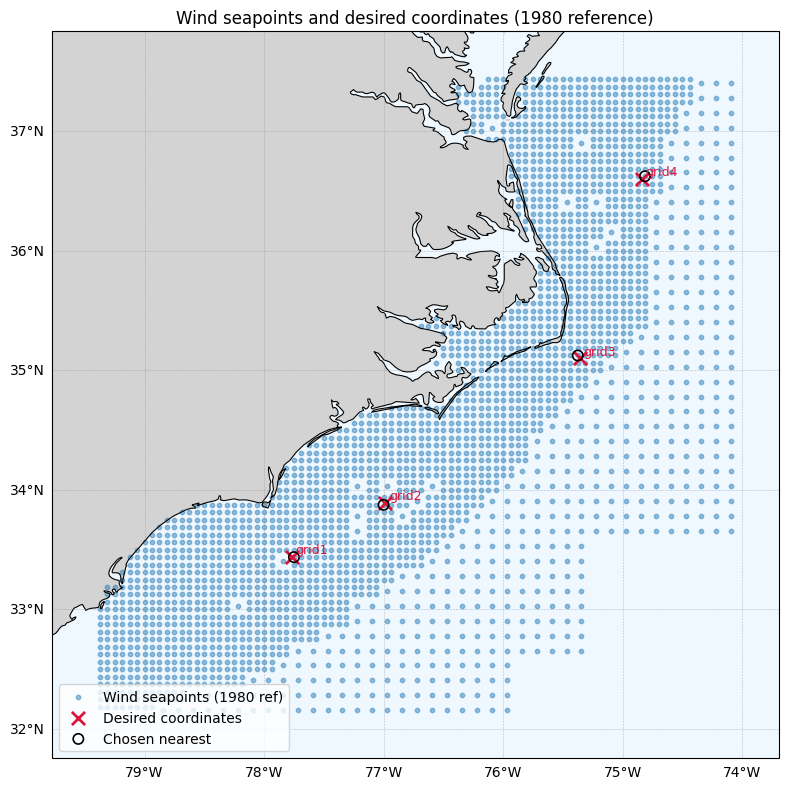

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Force 1980+ reference for plotted wind grid
START_DATE = "1980-01-01"
time_ref = np.datetime64(START_DATE)

wind_lats = uwnd.latitude.sel(time=time_ref).values
wind_lons = uwnd.longitude.sel(time=time_ref).values

target_names = list(TARGET_POINTS.keys())
target_lats = [TARGET_POINTS[k]["lat"] for k in target_names]
target_lons = [TARGET_POINTS[k]["lon"] for k in target_names]

# Recompute nearest for THIS exact plotted coordinate snapshot
plot_nearest_idx = {}
for name in target_names:
    pt = TARGET_POINTS[name]
    d = np.array(
        [haversine_km(pt["lat"], pt["lon"], la, lo) for la, lo in zip(wind_lats, wind_lons)]
    )
    plot_nearest_idx[name] = int(np.argmin(d))

nearest_lats = [wind_lats[plot_nearest_idx[k]] for k in target_names]
nearest_lons = [wind_lons[plot_nearest_idx[k]] for k in target_names]

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

all_lats = np.array(list(wind_lats) + target_lats)
all_lons = np.array(list(wind_lons) + target_lons)
ax.set_extent(
    [
        float(np.nanmin(all_lons) - 0.4),
        float(np.nanmax(all_lons) + 0.4),
        float(np.nanmin(all_lats) - 0.4),
        float(np.nanmax(all_lats) + 0.4),
    ],
    crs=ccrs.PlateCarree(),
)

ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

ax.scatter(
    wind_lons, wind_lats, s=10, color="tab:blue", alpha=0.45,
    transform=ccrs.PlateCarree(), label="Wind seapoints (1980 ref)"
)
ax.scatter(
    target_lons, target_lats, s=90, color="crimson", marker="x", linewidths=2,
    transform=ccrs.PlateCarree(), label="Desired coordinates"
)
ax.scatter(
    nearest_lons, nearest_lats, s=55, facecolors="none", edgecolors="black",
    marker="o", linewidths=1.2, transform=ccrs.PlateCarree(),
    label="Chosen nearest"
)

for name, lon, lat in zip(target_names, target_lons, target_lats):
    ax.text(lon + 0.03, lat + 0.03, name, fontsize=9, color="crimson", transform=ccrs.PlateCarree())

ax.set_title("Wind seapoints and desired coordinates (1980 reference)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [10]:
# df_reset has time as column; filter by time range
df_reset[(df_reset["time"] >= "1980-01-09 00:00:00")]

,time,latitude,longitude,hs0,tp0,dp0,hs1,tp1,dp1,ws0,wd0
768,1980-01-09 00:00:00,33.4410,-77.7660,0.190321,3.207462,257.043793,1.161628,5.676017,213.630768,4.346263,293.025492
769,1980-01-09 00:00:00,33.8928,-76.9845,0.021489,2.607721,295.406952,1.186876,5.677886,212.837189,3.488553,332.700428
770,1980-01-09 00:00:00,35.1000,-75.3600,0.552015,3.605955,15.893236,1.161022,9.958192,62.983879,3.981206,25.277722
771,1980-01-09 00:00:00,36.6030,-74.8370,0.706083,3.780783,12.538882,0.904757,9.969284,62.532021,6.888396,27.681062
772,1980-01-09 01:00:00,33.4410,-77.7660,0.095787,2.891500,268.881042,1.129800,5.671141,213.343994,3.448188,299.538782
...,...,...,...,...,...,...,...,...,...,...,...
1539835,2023-12-31 22:00:00,36.6030,-74.8370,0.385670,3.255950,239.931580,0.489457,10.147433,106.766914,4.623851,248.428693
1539836,2023-12-31 23:00:00,33.4410,-77.7660,1.340088,5.133469,232.743088,0.342190,10.404208,109.500114,9.775480,239.237280
1539837,2023-12-31 23:00:00,33.8928,-76.9845,1.326520,5.134686,231.731277,0.356444,10.272058,104.469170,10.023971,241.389540
1539838,2023-12-31 23:00:00,35.1000,-75.3600,0.986716,5.478639,232.411880,0.738887,5.482986,191.241348,7.472617,254.475889



        -------------------------------------------------------------------
        | Initializing PCA reduction model with the following parameters:
        |    - n_components: 0.95
        |    - is_incremental: False
        | For more information, please refer to the documentation.
        -------------------------------------------------------------------
        


2026-07-08 12:10:58,498 - PCA - WARNING - Using 4 out of 4 available variablesIf this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-07-08 12:10:58,499 - PCA - WARNING - Using 4 out of 4 available variablesIf this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-07-08 12:10:58,499 - PCA - WARNING - Using 4 out of 4 available variablesIf this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-07-08 12:10:58,500 - PCA - WARNING - Using 4 out of 4 available variablesIf this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-07-08 12:10:58,501 - PCA - WARNING - Using 4 out of 4 available variablesIf this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-07-08 12:10:58,501 - PCA - WARNING - Using 4 out of 4 available variablesIf this is origin

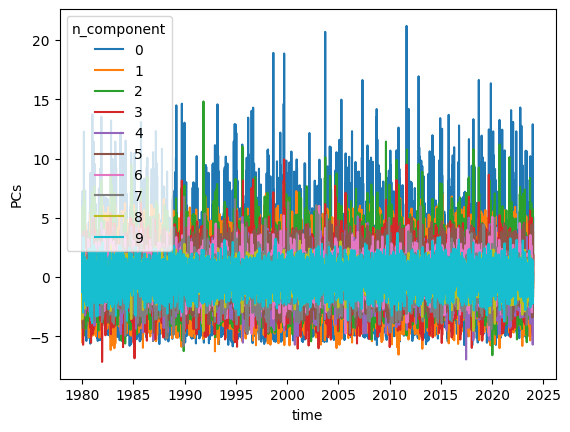

In [11]:
# Build PCA input from wide table so each g# keeps its physical coordinate.
grids_idx = [f"g{i}" for i in range(1, len(grids) + 1)]
grid_to_lat = {f"g{i}": TARGET_POINTS[f"grid{i}"]["lat"] for i in range(1, len(grids) + 1)}
grid_to_lon = {f"g{i}": TARGET_POINTS[f"grid{i}"]["lon"] for i in range(1, len(grids) + 1)}

# ----- hourly -> daily -----
df_pca_wide = df_reset_wide.copy()
df_pca_wide["time"] = pd.to_datetime(df_pca_wide["time"])
df_pca_wide = df_pca_wide.set_index("time").sort_index()

dir_cols = [c for c in df_pca_wide.columns if c.startswith(("dp", "wd"))]
non_dir_cols = [c for c in df_pca_wide.columns if c not in dir_cols]

def circular_mean_deg(s):
    rad = np.deg2rad(s.dropna())
    if len(rad) == 0:
        return np.nan
    ang = np.rad2deg(np.arctan2(np.sin(rad).mean(), np.cos(rad).mean()))
    return (ang + 360) % 360

daily = df_pca_wide[non_dir_cols].resample("D").mean()
for c in dir_cols:
    daily[c] = df_pca_wide[c].resample("D").apply(circular_mean_deg)

# optional final fill for any remaining gaps
daily = daily.interpolate(method="time", limit_direction="both").bfill().ffill()

if use_PCA:
    pca = PCA(n_components=0.95)
    pca_vars = ["hs0", "tp0", "dp0", "hs1", "tp1", "dp1", "ws0", "wd0"]

    ds_vars = {}
    for base_var in pca_vars:
        cols = [f"{base_var}{g}" for g in grids_idx]
        ds_vars[base_var] = (("time", "grid"), daily[cols].to_numpy())

    ds_pca = xr.Dataset(
        data_vars=ds_vars,
        coords={
            "time": daily.index.values,
            "grid": grids_idx,
            "latitude": ("grid", [grid_to_lat[g] for g in grids_idx]),
            "longitude": ("grid", [grid_to_lon[g] for g in grids_idx]),
        },
    )

    pca.fit_transform(
        data=ds_pca,
        vars_to_stack=pca_vars,
        coords_to_stack=["grid"],
        pca_dim_for_rows="time",
    )

    pca.plot_pcs(num_pcs=10)
    data = pca.pcs_df.copy()
    feature_cols = [c for c in data.columns if c.startswith("PC")]
    if len(feature_cols) == 0:
        raise ValueError("use_PCA=True but no PC columns were generated in pca.pcs_df")
    data = data.loc[:, feature_cols]
else:
    data = daily.copy()
    feature_cols = [
        c for c in data.columns
        if c.startswith(("hs", "tp", "ws", "dp", "wd"))
    ]

# Keep a deterministic ordering for downstream MDA/KMA
if len(feature_cols) == 0:
    raise ValueError("No feature columns found for clustering")

data.index = pd.to_datetime(data.index)
data = data.sort_index()
feature_cols = list(data.columns)


In [12]:
data.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
1980-01-01,0.619855,-1.292098,-2.979650,-1.874167,1.823666,-1.889442,0.328605,0.572648,1.818576,-1.118854,0.553774,-1.635412,-1.320633,2.256849
1980-01-02,3.776736,2.170439,0.828006,-1.223420,2.339741,-1.935077,0.511117,-0.936700,-0.290170,-1.283785,0.233727,-1.810496,-0.666133,-1.097558
1980-01-03,-1.559385,1.495612,3.756596,-2.543712,2.095535,0.315672,-0.756117,0.162446,-1.195109,0.690312,0.156136,1.276504,1.426322,-0.122977
1980-01-04,-1.521929,-3.672464,0.293766,-1.944003,1.811750,-0.881205,1.323161,0.007692,-0.214386,0.142603,-0.000686,0.255574,-0.013191,0.392484
1980-01-05,4.923933,2.971154,0.980235,-0.534036,2.360283,-2.627799,1.552745,-2.051353,0.094612,2.285852,-0.083389,0.093646,0.990989,-0.891518


In [ ]:
# date_to_check = "1980-01-09"
# data_daily = data
# row = data_daily.loc[date_to_check]
# nan_vars = row[row.isna()].index.tolist()
# print(f"{date_to_check}: NaNs in {len(nan_vars)} variable(s): {nan_vars}")
# print(f"\nFull row (NaN = missing):\n{row}")

## MDA

In [13]:
n_clusters = 5000

mda_ob = MDA(num_centers=n_clusters)
mda_ob.logger_disabled = True
custom_scale_factor = {}

if use_PCA:
    columns_names = tuple(c for c in data.columns if c.startswith("PC"))
    dir_vars = []
else:
    columns_names = tuple(c for c in data.columns if c.startswith(("hs", "tp", "ws", "dp", "wd")))
    dir_vars = [
        'dp0g1', 'dp0g2', 'dp0g3', 'dp0g4',
        'dp1g1', 'dp1g2', 'dp1g3', 'dp1g4',
        'wd0g1', 'wd0g2', 'wd0g3', 'wd0g4',
    ]

if len(columns_names) == 0:
    raise ValueError("No clustering columns found for MDA")

# 1) Feature variables: data-based [min, max]
for col in columns_names:
    vmin = float(data[col].min())
    vmax = float(data[col].max())
    if vmin == vmax:
        vmax = vmin + 1e-6
    custom_scale_factor[col] = [vmin, vmax]

# 2) Directional variables: weaken their influence via u/v scales
for dv in dir_vars:
    custom_scale_factor[f"{dv}_u"] = [-1.5, 1.5]
    custom_scale_factor[f"{dv}_v"] = [-1.5, 1.5]

# 3) Fit MDA
mda_ob.fit(
    data=data.loc[:, list(columns_names)],
    directional_variables=dir_vars,
    normalize_data=True,
    custom_scale_factor=custom_scale_factor,
)

if len(mda_ob.centroid_real_indices) == 0:
    raise ValueError("MDA returned no centroid_real_indices")


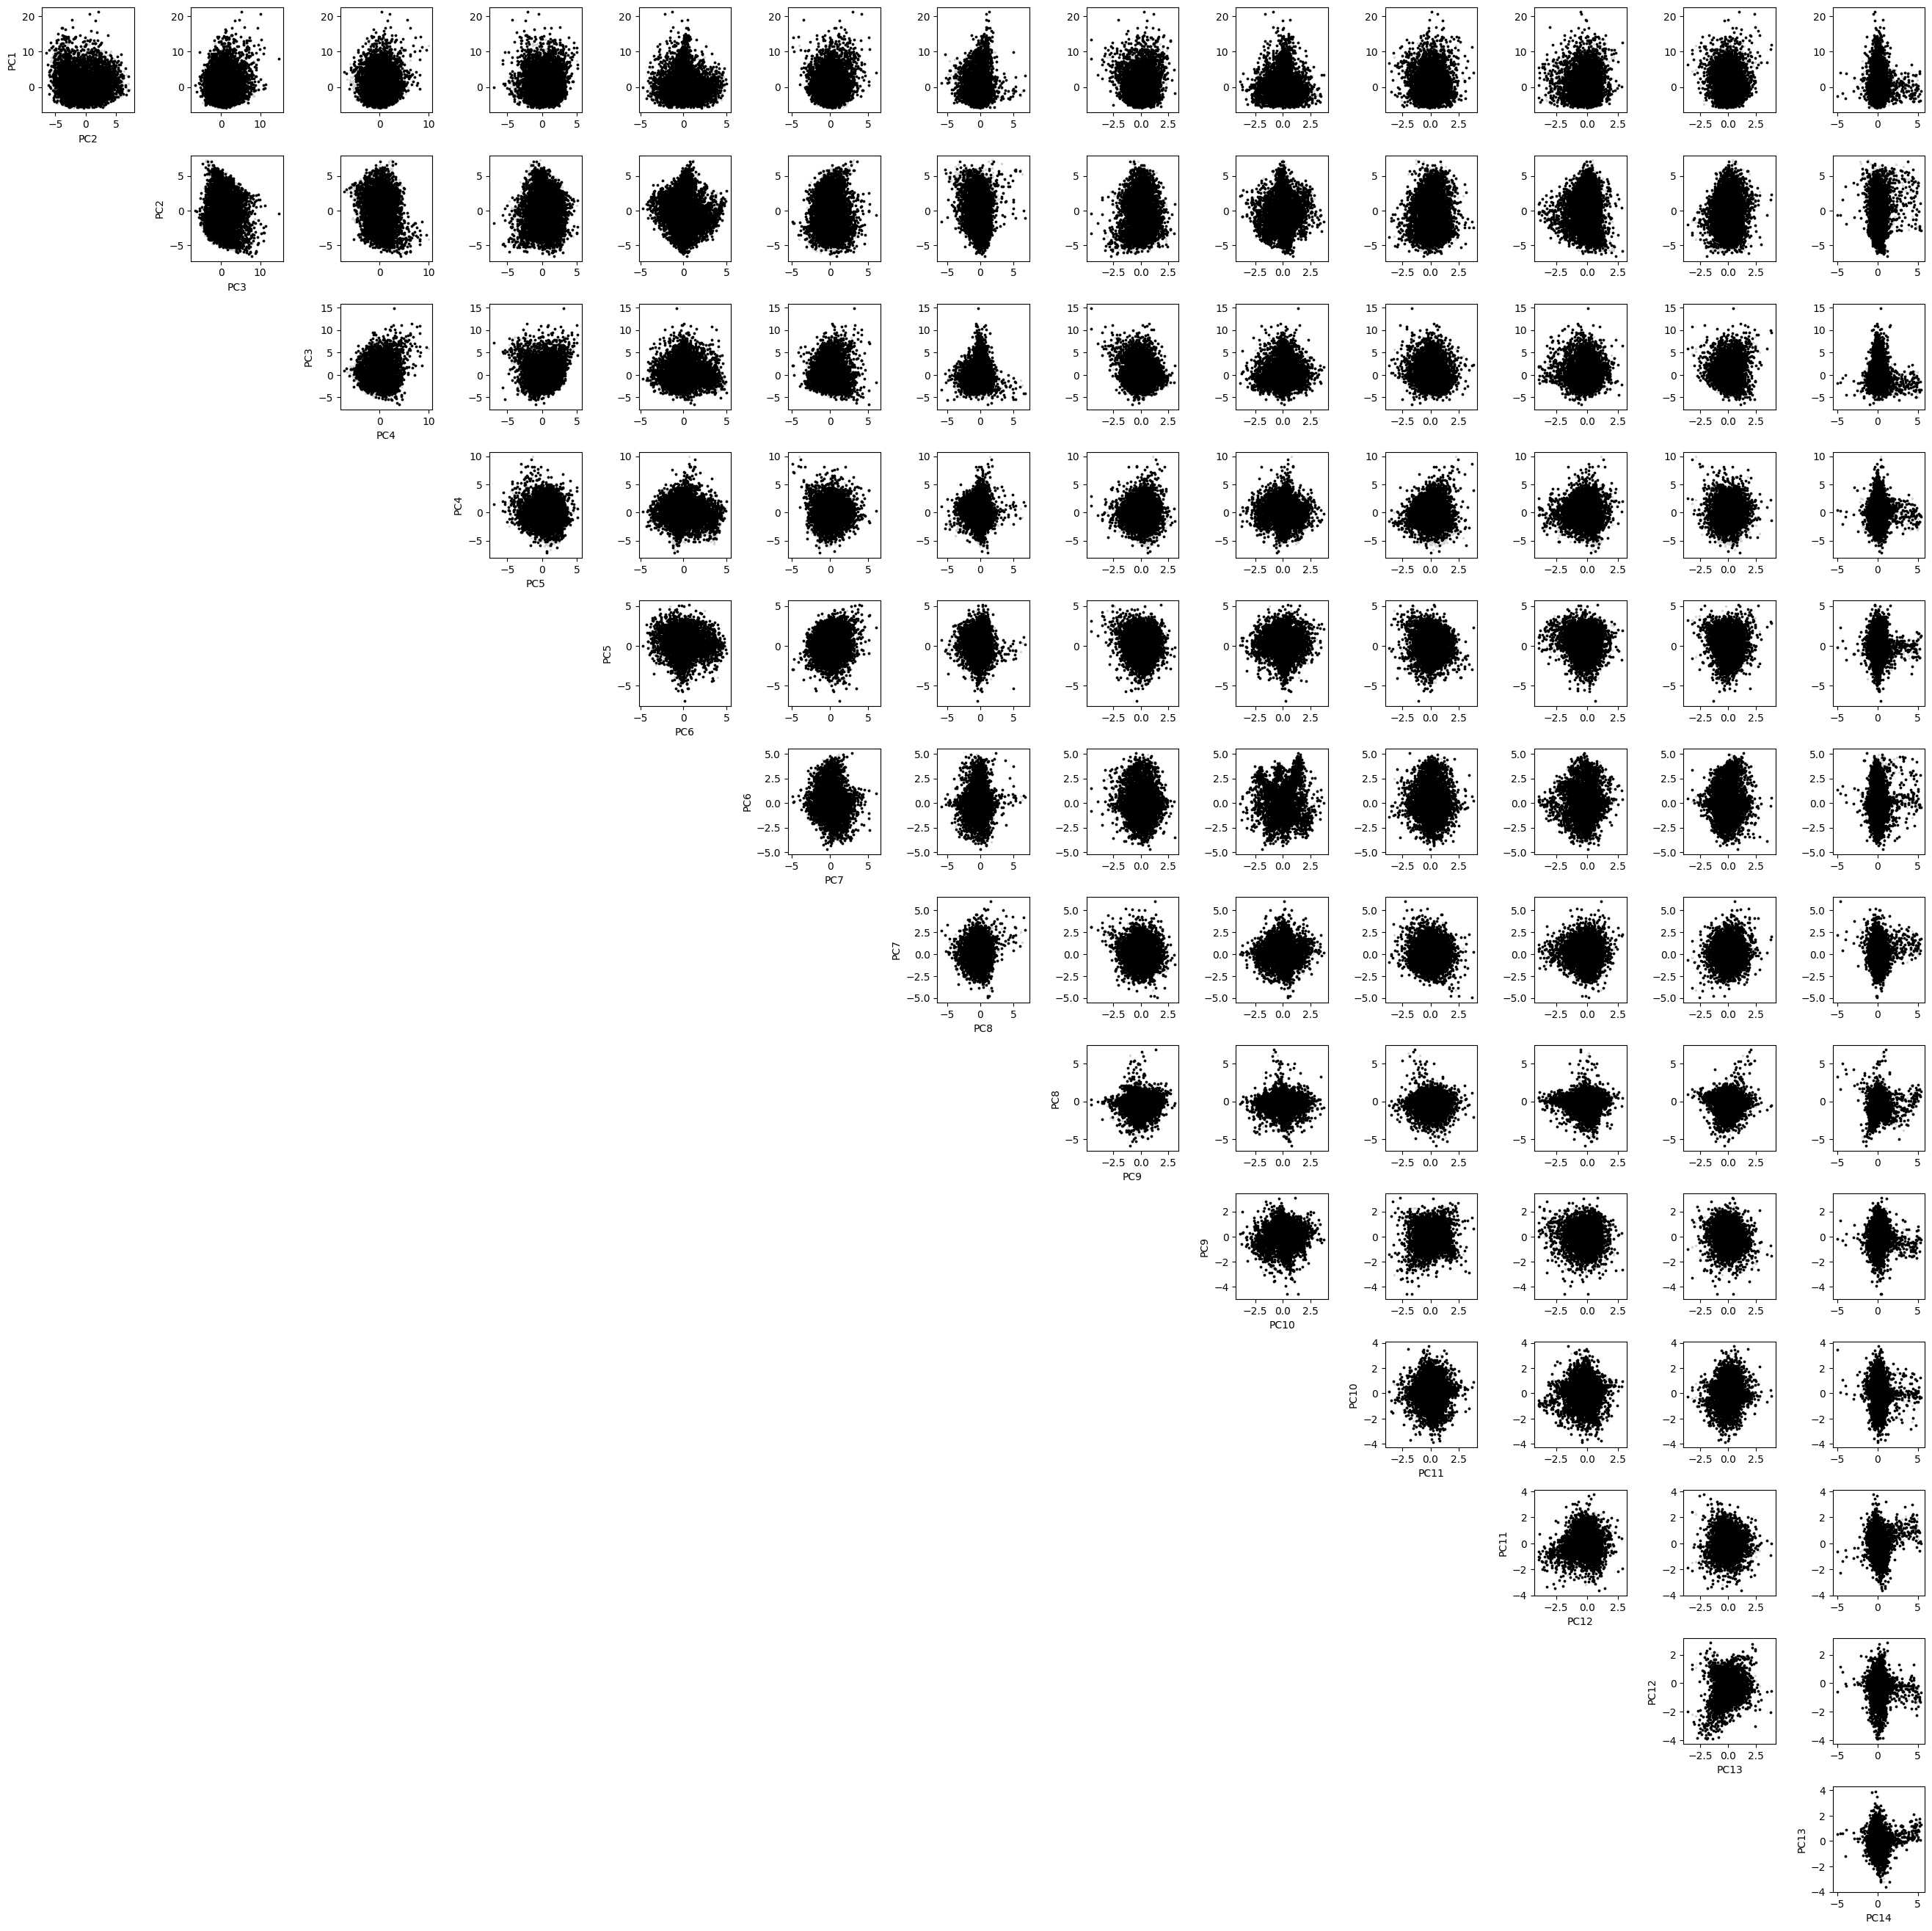

In [15]:
fig, axes = plt.subplots(len(data.columns),len(data.columns), figsize=(2*len(data.columns), 2*len(data.columns)))

for i in range(len(data.columns)):
    for j in range(len(data.columns)):
        if i >= j:              # lower triangle
            axes[i, j].set_visible(False)
        else:
            axes[i,j].scatter(data[data.columns[j]],data[data.columns[i]], color='lightgray',s=2)
            axes[i,j].scatter(mda_ob.centroids[data.columns[j]], mda_ob.centroids[data.columns[i]], color='k',s=3)
            if j-i == 1:
                axes[i,j].set_xlabel(data.columns[j])
                axes[i,j].set_ylabel(data.columns[i])

plt.tight_layout()
# Save figure
fig.savefig(f'outputs/Figures/correlation_matrix_data_MDA_Waves.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Build KMA training dataframe directly from current MDA output
kma_df = data.iloc[mda_ob.centroid_real_indices].copy()

if use_PCA:
    kma_feature_cols = [c for c in kma_df.columns if c.startswith("PC")]
else:
    kma_feature_cols = [
        c for c in kma_df.columns
        if c.startswith(("hs", "tp", "ws", "dp", "wd"))
    ]

if len(kma_feature_cols) == 0:
    raise ValueError("No KMA feature columns found in kma_df")

kma_df = kma_df.loc[:, kma_feature_cols].sort_index()
print("kma_df shape:", kma_df.shape)


kma_df shape: (5000, 14)


#### K-medoids from MDA

In [17]:
n_clusters = 144
kma_ob = KMA(num_clusters=n_clusters, seed=0, algorithm="kmeans")
kma_ob.logger_disabled = True
custom_scale_factor = {}

# Rebuild kma_df from current MDA state to avoid stale notebook variables
kma_df = data.iloc[mda_ob.centroid_real_indices].copy()

if use_PCA:
    columns_names = tuple(c for c in kma_df.columns if c.startswith("PC"))
    dir_vars = []
else:
    columns_names = tuple(c for c in kma_df.columns if c.startswith(("hs", "tp", "ws", "dp", "wd")))
    dir_vars = [
        'dp0g1', 'dp0g2', 'dp0g3', 'dp0g4',
        'dp1g1', 'dp1g2', 'dp1g3', 'dp1g4',
        'wd0g1', 'wd0g2', 'wd0g3', 'wd0g4',
    ]

if len(columns_names) == 0:
    raise ValueError("No clustering columns found for KMA")

kma_df = kma_df.loc[:, list(columns_names)].sort_index()
print("KMA scaling source: kma_df (from MDA centroid_real_indices)")
print("kma_df rows/features:", kma_df.shape)

# 1) Feature variables: data-based [min, max]
for col in columns_names:
    vmin = float(kma_df[col].min())
    vmax = float(kma_df[col].max())
    if vmin == vmax:
        vmax = vmin + 1e-6
    custom_scale_factor[col] = [vmin, vmax]

# 2) Directional variables: weaken their influence via u/v scales
for dv in dir_vars:
    custom_scale_factor[f"{dv}_u"] = [-1.5, 1.5]
    custom_scale_factor[f"{dv}_v"] = [-1.5, 1.5]

# 3) Fit KMA with k-medoids
kma_ob.fit(
    data=kma_df,
    directional_variables=dir_vars,
    normalize_data=True,
    custom_scale_factor=custom_scale_factor,
    min_number_of_points=5,
)


KMA scaling source: kma_df (from MDA centroid_real_indices)
kma_df rows/features: (5000, 14)


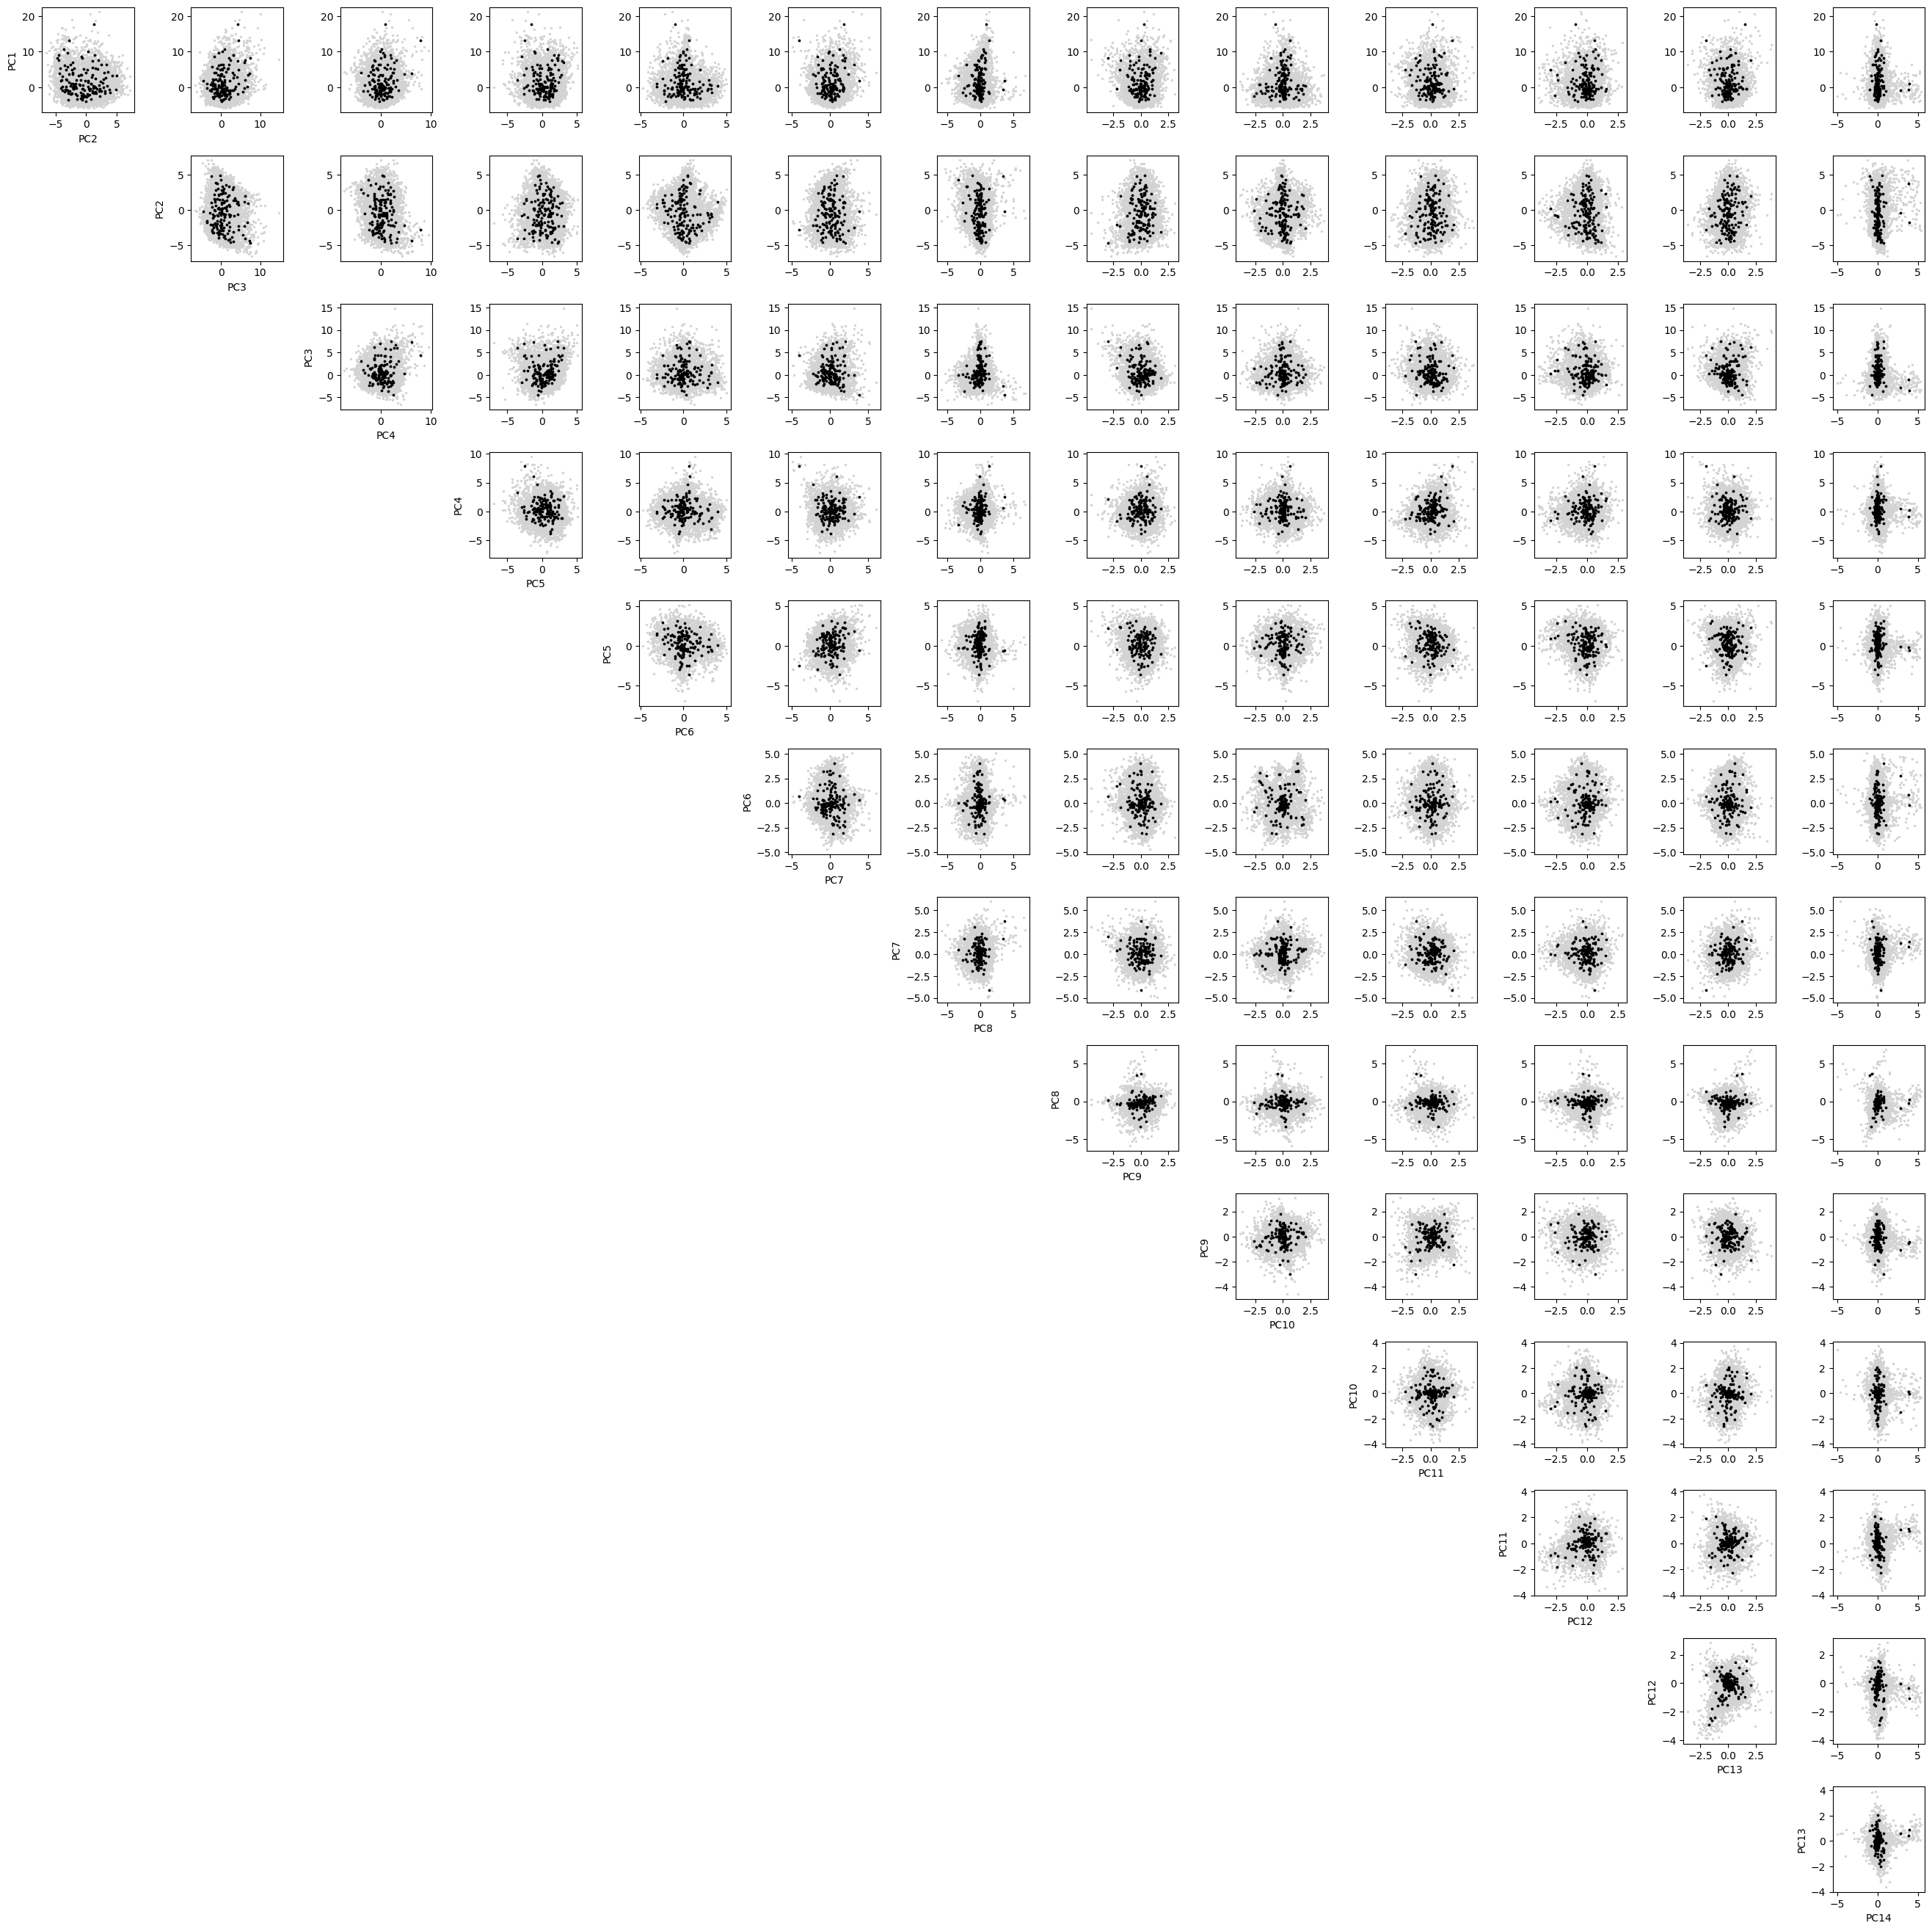

In [18]:
fig, axes = plt.subplots(len(kma_df.columns),len(kma_df.columns), figsize=(2*len(kma_df.columns), 2*len(kma_df.columns)))

for i in range(len(kma_df.columns)):
    for j in range(len(kma_df.columns)):
        if i >= j:              # lower triangle
            axes[i, j].set_visible(False)
        else:
            axes[i,j].scatter(kma_df[kma_df.columns[j]],kma_df[kma_df.columns[i]], color='lightgray',s=2)
            axes[i,j].scatter(kma_ob.centroids[kma_df.columns[j]], kma_ob.centroids[kma_df.columns[i]], color='k',s=3)
            if j-i == 1:
                axes[i,j].set_xlabel(kma_df.columns[j])
                axes[i,j].set_ylabel(kma_df.columns[i])

plt.tight_layout()
# Save figure
fig.savefig(f'outputs/Figures/correlation_matrix_kma_Waves.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
kma_ob.centroids

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
0,0.099306,-3.911079,-0.587737,0.599351,0.686840,-0.495559,-1.005177,0.115941,-0.119156,0.163866,0.332131,0.196199,0.081037,0.118823
1,-1.747420,-2.873128,-0.408958,-0.413325,-0.298761,1.251718,-1.671026,-0.533081,-0.092339,-1.643448,-0.623899,0.227600,0.260881,0.033474
2,-3.492327,-2.916338,0.498289,0.720961,0.432618,0.834688,-0.008378,-0.116390,-0.105077,-1.063801,0.230834,-0.144719,0.297168,-0.181293
3,8.723427,-0.769458,-1.681671,0.728819,-2.935513,-0.452933,-1.630234,0.093450,-0.206625,0.456762,0.954945,-0.567947,0.083168,-0.394087
4,-0.921584,-3.064216,3.087464,3.586370,1.158486,0.672543,0.089719,0.045185,0.520480,-0.185042,0.847645,-0.116131,0.491639,-0.172215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.291908,-2.111185,-2.020073,0.408672,-1.320994,-0.382077,-0.780887,-0.537282,0.607254,-0.050593,-0.575653,-0.089561,0.348890,-0.070548
140,-0.274518,-1.801751,0.185779,-0.013671,1.491279,-1.819695,0.700899,0.313850,0.662095,-0.621582,-0.459353,-1.233938,-0.733047,0.719224
141,-0.048872,1.464028,-1.611733,0.516719,0.111871,0.087439,0.166052,-0.288414,-0.175315,0.109789,-0.457463,0.408229,-0.333486,-0.108599
142,1.040498,-2.214624,-2.024025,-0.532100,-0.940324,-0.654104,-1.805707,-0.285271,-0.487465,0.203077,0.391300,-0.301878,0.077755,-0.071526


In [22]:
# Predict on the same feature set used to train KMA
predict_data = data.loc[:, list(kma_df.columns)].copy().sort_index()
print("Predict data aligned to KMA training columns:", len(kma_df.columns), "features")

nearest_centroids_idxs, nearest_centroids_df = kma_ob.predict(data=predict_data)

if len(nearest_centroids_idxs) != len(predict_data):
    raise ValueError(
        f"Prediction length mismatch: {len(nearest_centroids_idxs)} vs {len(predict_data)}"
    )


Predict data aligned to KMA training columns: 14 features


In [24]:
#save as csv
kma_ob.centroids.to_csv(f'outputs/KMA/centroids_kma_pcs.csv')
nearest_centroids_idxs.to_csv(f'outputs/KMA/nearest_centroids_idxs_kma_pcs.csv')
nearest_centroids_df.to_csv(f'outputs/KMA/nearest_centroids_df_kma_pcs.csv')


In [25]:
kma_ob.centroids

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
0,0.099306,-3.911079,-0.587737,0.599351,0.686840,-0.495559,-1.005177,0.115941,-0.119156,0.163866,0.332131,0.196199,0.081037,0.118823
1,-1.747420,-2.873128,-0.408958,-0.413325,-0.298761,1.251718,-1.671026,-0.533081,-0.092339,-1.643448,-0.623899,0.227600,0.260881,0.033474
2,-3.492327,-2.916338,0.498289,0.720961,0.432618,0.834688,-0.008378,-0.116390,-0.105077,-1.063801,0.230834,-0.144719,0.297168,-0.181293
3,8.723427,-0.769458,-1.681671,0.728819,-2.935513,-0.452933,-1.630234,0.093450,-0.206625,0.456762,0.954945,-0.567947,0.083168,-0.394087
4,-0.921584,-3.064216,3.087464,3.586370,1.158486,0.672543,0.089719,0.045185,0.520480,-0.185042,0.847645,-0.116131,0.491639,-0.172215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.291908,-2.111185,-2.020073,0.408672,-1.320994,-0.382077,-0.780887,-0.537282,0.607254,-0.050593,-0.575653,-0.089561,0.348890,-0.070548
140,-0.274518,-1.801751,0.185779,-0.013671,1.491279,-1.819695,0.700899,0.313850,0.662095,-0.621582,-0.459353,-1.233938,-0.733047,0.719224
141,-0.048872,1.464028,-1.611733,0.516719,0.111871,0.087439,0.166052,-0.288414,-0.175315,0.109789,-0.457463,0.408229,-0.333486,-0.108599
142,1.040498,-2.214624,-2.024025,-0.532100,-0.940324,-0.654104,-1.805707,-0.285271,-0.487465,0.203077,0.391300,-0.301878,0.077755,-0.071526


In [26]:
nearest_centroids_idxs

,kma_bmus
1980-01-01,140
1980-01-02,106
1980-01-03,50
1980-01-04,28
1980-01-05,11
...,...
2023-12-27,33
2023-12-28,38
2023-12-29,102
2023-12-30,78


In [27]:
nearest_centroids_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
140,-0.274518,-1.801751,0.185779,-0.013671,1.491279,-1.819695,0.700899,0.313850,0.662095,-0.621582,-0.459353,-1.233938,-0.733047,0.719224
106,-0.062442,1.349026,1.419215,-0.403594,1.349734,-1.292453,-0.009482,0.210630,-0.090546,-1.521701,-0.361279,-1.567511,-0.945183,-0.259776
50,-0.475143,1.686311,3.539084,-1.286507,1.771291,-0.256143,-0.443123,-0.346635,-0.915664,-0.118585,-0.130130,0.311553,0.661228,-0.002072
28,-0.966169,-2.735623,-0.987642,-0.871301,1.740715,-0.652433,1.230668,-0.348860,0.219647,-0.099431,0.069974,0.460477,-0.049443,-0.166437
11,0.689280,2.133498,-0.606436,0.314826,1.178305,-2.192460,0.422474,-1.711450,0.254250,1.858908,0.200644,-0.375361,0.058136,-0.223742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,5.321597,-1.959639,-0.946242,-0.645636,-0.097479,-0.444962,-0.974838,0.651349,0.211124,0.171993,0.031240,0.478441,-0.452683,-0.036441
38,2.901114,0.911897,4.049817,2.026079,2.576065,-0.861238,-0.965882,-0.355987,-0.773902,0.161338,-0.317360,-0.582944,1.306231,-0.300128
102,-1.767424,1.277980,0.932334,-0.009059,-1.012058,-0.646137,-1.131119,-0.044848,-0.160018,-0.000169,-0.203423,-0.416746,0.026197,0.267797
78,2.209151,2.856654,-1.323335,1.538309,-0.808201,-0.043527,-0.926678,-0.161790,-0.853041,0.022899,-0.377554,-0.334400,0.353200,0.055339


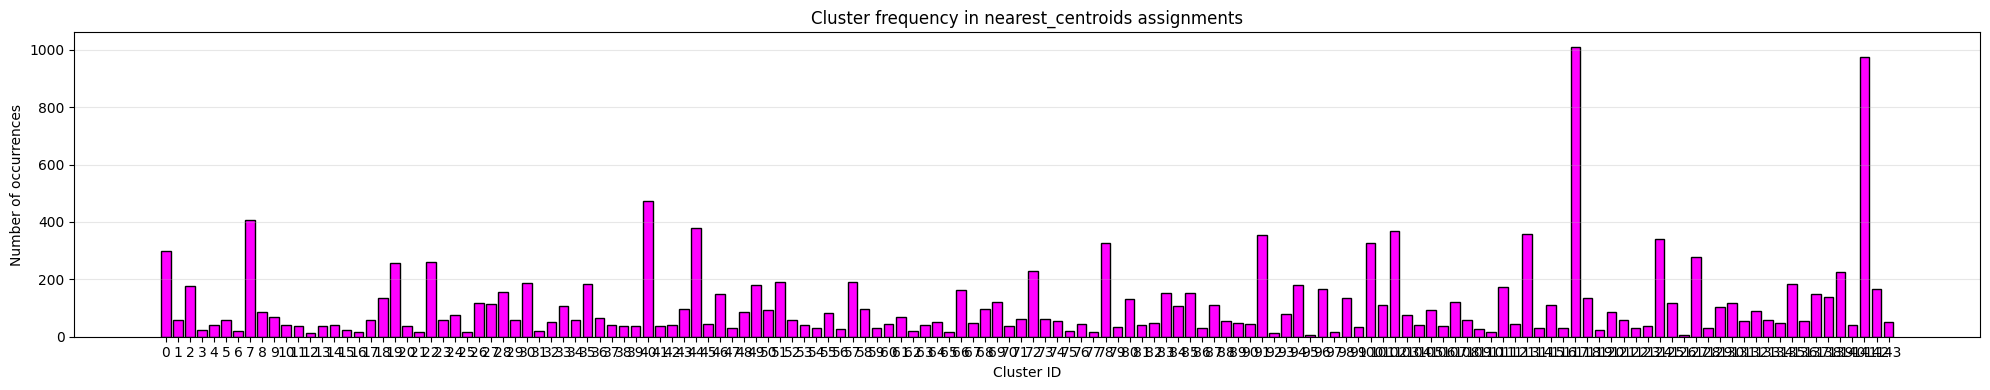

In [28]:
# Histogram: how often each cluster appears in the KMA assignments

# Use the labels from nearest_centroids_idxs (each row = one time step)
cluster_ids = nearest_centroids_idxs["kma_bmus"]

# Count occurrences per cluster ID
cluster_counts = cluster_ids.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(20, 4))
ax.bar(cluster_counts.index, cluster_counts.values, width=0.8, color='fuchsia', edgecolor="k")

ax.set_xlabel("Cluster ID")
ax.set_ylabel("Number of occurrences")
ax.set_title("Cluster frequency in nearest_centroids assignments")
ax.set_xticks(cluster_counts.index)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
# Save figure
fig.savefig(f'outputs/Figures/histogram_cluster_frequency_KMA.png', dpi=150, bbox_inches='tight')

plt.show()

In [29]:
# Attach ORIGINAL BMUs from nearest_centroids_idxs to daily dataframe
# (run this after `nearest_centroids_idxs` is created)

# Choose your daily frame source
if "daily" in globals():
    daily_with_bmus = daily.copy()
else:
    daily_with_bmus = data.copy()

daily_with_bmus.index = pd.to_datetime(daily_with_bmus.index)

bmus_daily = nearest_centroids_idxs.copy()
bmus_daily.index = pd.to_datetime(bmus_daily.index)

# Match by date (robust to timestamp hour differences)
daily_with_bmus["date"] = daily_with_bmus.index.normalize()
bmus_daily["date"] = bmus_daily.index.normalize()

# Keep one original label per day and join only kma_bmus
bmus_by_date = bmus_daily.drop_duplicates(subset=["date"]).set_index("date")
daily_with_bmus = daily_with_bmus.join(bmus_by_date[["kma_bmus"]], on="date", how="left")

daily_with_bmus = daily_with_bmus.drop(columns=["date"])

print("daily_with_bmus shape:", daily_with_bmus.shape)
print("Rows without kma_bmus:", int(daily_with_bmus["kma_bmus"].isna().sum()))
daily_with_bmus.head()

daily_with_bmus shape: (16071, 33)
Rows without kma_bmus: 0


,hs0g1,tp0g1,hs1g1,tp1g1,hs0g2,tp0g2,hs1g2,tp1g2,hs0g3,tp0g3,...,dp1g2,dp0g3,dp1g3,dp0g4,dp1g4,wd0g1,wd0g2,wd0g3,wd0g4,kma_bmus
time,,,,,,,,,,,,,,,,,,,,,
1980-01-01,0.504218,4.407562,0.941927,5.509542,1.092657,5.538350,1.003170,5.698326,1.182951,4.826117,...,87.456085,36.762909,146.434998,42.303162,30.113525,343.059347,357.431806,28.793336,46.879320,140
1980-01-02,1.109726,4.669451,1.124877,7.137868,1.118281,4.936560,1.385420,6.841274,1.718988,6.411386,...,85.963379,6.120483,70.231689,8.173706,74.062805,313.736234,318.592456,336.293129,346.699814,106
1980-01-03,0.309096,3.182370,0.612484,9.368897,0.289012,3.217473,0.769247,8.450166,0.583798,4.959516,...,62.904877,345.953613,50.527283,333.084839,54.089111,0.701913,349.223979,339.195547,327.400677,50
1980-01-04,0.182427,2.909696,0.546047,9.211833,0.306896,3.902409,0.782542,6.842764,0.685079,5.999275,...,64.404175,70.481750,50.212250,46.614288,44.358154,98.817560,99.419199,68.972997,47.526108,28
1980-01-05,1.289812,4.874638,1.083421,6.654879,1.219720,4.865240,1.161102,6.588326,1.404817,7.689563,...,156.619568,358.071899,54.617310,33.345734,92.664429,318.105656,318.722730,320.125084,16.728776,11


In [30]:
# Convert PC-based KMA assignments back to ORIGINAL 32-variable daily space
# Goal:
# 1) Keep BMUs from KMA-on-PCs (date -> kma_bmus)
# 2) Build nearest_centroids_idxs / nearest_centroids_df
# 3) Build kma_ob_32-like object with centroids in 32-variable space

from types import SimpleNamespace

# 32-variable columns in original daily space
vars32 = [
    c for c in daily_with_bmus.columns
    if c.startswith(("hs0g", "hs1g", "tp0g", "tp1g", "dp0g", "dp1g", "ws0g", "wd0g"))
]
vars32 = sorted(vars32)
if len(vars32) == 0:
    raise ValueError("No 32-variable columns found in daily_with_bmus.")

# BMUs from PC-based KMA
bmus = nearest_centroids_idxs[["kma_bmus"]].copy()
bmus.index = pd.to_datetime(bmus.index)

# Daily original-variable dataframe aligned to BMU dates
daily32 = daily_with_bmus.copy()
daily32.index = pd.to_datetime(daily32.index)

daily32_aligned = daily32.reindex(bmus.index)

# Equivalent of nearest_centroids_df but in 32-variable space
nearest_centroids_df_waves = daily32_aligned[vars32].copy()
nearest_centroids_df_waves["kma_bmus"] = bmus["kma_bmus"].values

# Equivalent of nearest_centroids_idxs (same BMUs, date index)
nearest_centroids_idxs_waves = bmus.copy()

# Equivalent of kma_ob.centroids in 32-variable space:
# centroid for each cluster = mean of original variables for dates assigned to that cluster
kma_centroids_32 = (
    nearest_centroids_df_waves
    .dropna(subset=["kma_bmus"])
    .groupby("kma_bmus")[vars32]
    .mean()
    .sort_index()
)

# Lightweight object so downstream code can use kma_ob_32.centroids
kma_ob_waves= SimpleNamespace(centroids=kma_centroids_32)

print("vars32:", len(vars32))
print("nearest_centroids_idxs_32:", nearest_centroids_idxs_waves.shape)
print("nearest_centroids_df_32:", nearest_centroids_df_waves.shape)
print("kma_ob_32.centroids:", kma_ob_waves.centroids.shape)

# # Save files
nearest_centroids_idxs_waves.to_csv(f"outputs/KMA/nearest_centroids_idxs_kma_waves.csv")
nearest_centroids_df_waves.to_csv(f"outputs/KMA/nearest_centroids_df_kma_waves.csv")
kma_ob_waves.centroids.to_csv(f"outputs/KMA/centroids_kma_waves.csv")

vars32: 32
nearest_centroids_idxs_32: (16071, 1)
nearest_centroids_df_32: (16071, 33)
kma_ob_32.centroids: (144, 32)


In [31]:
nearest_centroids_df_waves.head()

,dp0g1,dp0g2,dp0g3,dp0g4,dp1g1,dp1g2,dp1g3,dp1g4,hs0g1,hs0g2,...,tp1g4,wd0g1,wd0g2,wd0g3,wd0g4,ws0g1,ws0g2,ws0g3,ws0g4,kma_bmus
1980-01-01,11.369049,23.596039,36.762909,42.303162,83.274261,87.456085,146.434998,30.113525,0.504218,1.092657,...,4.954474,343.059347,357.431806,28.793336,46.879320,6.794482,8.926181,10.832924,8.401535,140
1980-01-02,311.676697,324.960144,6.120483,8.173706,171.626465,85.963379,70.231689,74.062805,1.109726,1.118281,...,6.988623,313.736234,318.592456,336.293129,346.699814,9.916078,10.299135,12.306847,11.604951,106
1980-01-03,353.975891,343.836151,345.953613,333.084839,70.085419,62.904877,50.527283,54.089111,0.309096,0.289012,...,8.358103,0.701913,349.223979,339.195547,327.400677,4.958947,5.421560,6.140924,7.739953,50
1980-01-04,66.610535,84.603668,70.481750,46.614288,70.112457,64.404175,50.212250,44.358154,0.182427,0.306896,...,7.986774,98.817560,99.419199,68.972997,47.526108,4.228852,4.961302,6.692020,7.123397,28
1980-01-05,318.671417,313.440186,358.071899,33.345734,173.840637,156.619568,54.617310,92.664429,1.289812,1.219720,...,7.691811,318.105656,318.722730,320.125084,16.728776,10.617166,10.577474,10.336028,12.739545,11


In [32]:
nearest_centroids_idxs_waves.head()

,kma_bmus
1980-01-01,140
1980-01-02,106
1980-01-03,50
1980-01-04,28
1980-01-05,11


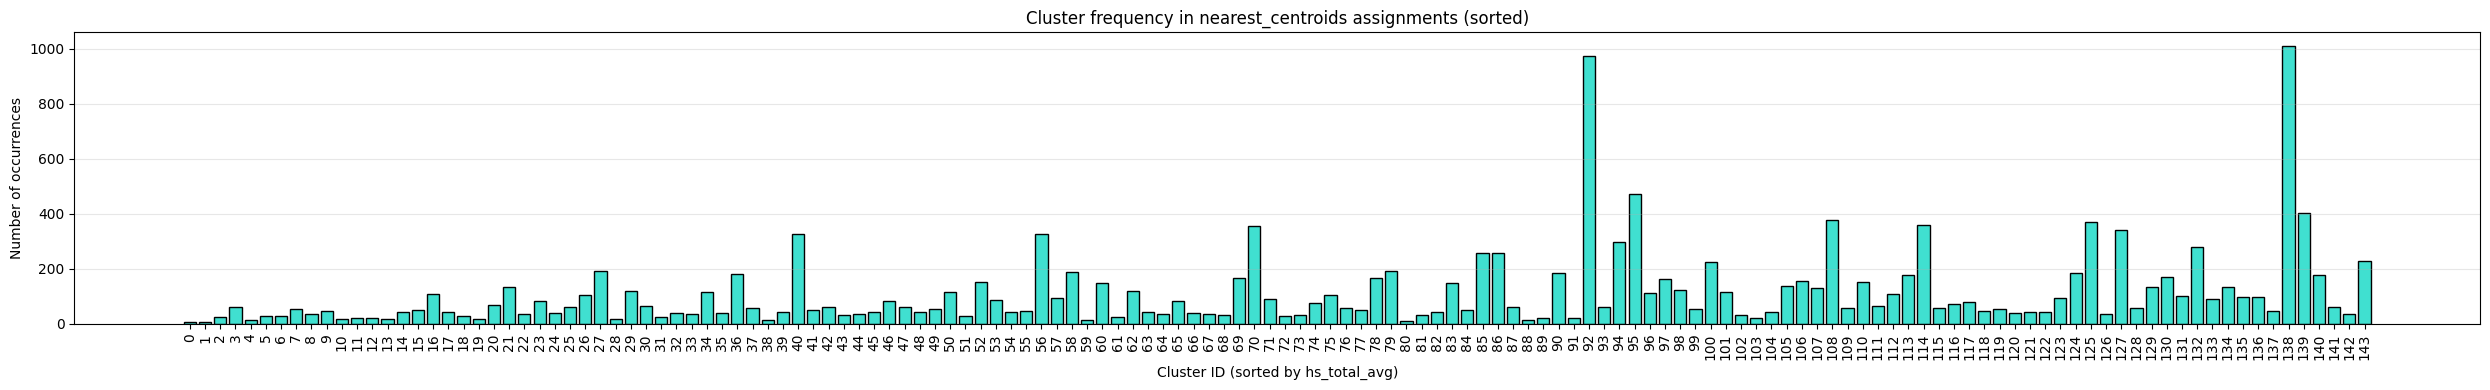

In [33]:
# 1) Order of clusters from kma_sort (highest hs_total_avg first)
hs0g_cols = ['hs0g1', 'hs0g2', 'hs0g3', 'hs0g4']
hs1g_cols = ['hs1g1', 'hs1g2', 'hs1g3', 'hs1g4']
hs_total_cols = [f"hs_totalg{i}" for i in range(1, 5)]

centroids_with_total = kma_ob_waves.centroids.copy()
for i in range(1, 5):
    centroids_with_total[f"hs_totalg{i}"] = (
        centroids_with_total[f"hs0g{i}"] + centroids_with_total[f"hs1g{i}"]
    )

kma_sort = centroids_with_total.assign(
    hs_total_avg=centroids_with_total[hs_total_cols].mean(axis=1)
).sort_values(by='hs_total_avg', ascending=False)

# Old cluster IDs in desired order
cluster_order = list(kma_sort.index)

# Mapping: old_id -> new_id (0-based; use start=1 for 1-based)
mapping = {old: new for new, old in enumerate(cluster_order, start=0)}

# 2) Apply mapping to nearest_centroids_idxs_waves
#    (keep original labels in case they are needed later)
if 'kma_bmus_orig' not in nearest_centroids_idxs_waves.columns:
    nearest_centroids_idxs_waves['kma_bmus_orig'] = nearest_centroids_idxs_waves['kma_bmus']

nearest_centroids_idxs_waves['kma_bmus_sorted'] = nearest_centroids_idxs_waves['kma_bmus'].map(mapping)

# 3) (Optional but often useful) Attach sorted cluster ID to nearest_centroids_df
#    Indices of both dfs are datetimes, so this aligns row by row.
nearest_centroids_df_waves = nearest_centroids_df_waves.copy()
nearest_centroids_df_waves['kma_bmus_sorted'] = (
    nearest_centroids_idxs_waves['kma_bmus_sorted'].reindex(nearest_centroids_df_waves.index)
)
# Saving sorted files
nearest_centroids_idxs_waves.to_csv(f'outputs/KMA/nearest_centroids_idxs_kma_sorted.csv')
nearest_centroids_df_waves.to_csv(f'outputs/KMA/nearest_centroids_df_kma_sorted.csv')
kma_sort.to_csv(f'outputs/KMA/centroids_kma_sorted.csv')

# 4) Histogram using the sorted cluster IDs
cluster_ids_sorted = nearest_centroids_idxs_waves['kma_bmus_sorted']
cluster_counts_sorted = cluster_ids_sorted.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(25, 4))
ax.bar(cluster_counts_sorted.index, cluster_counts_sorted.values,
       width=0.8, color="turquoise", edgecolor="k")

ax.set_xlabel("Cluster ID (sorted by hs_total_avg)")
ax.set_ylabel("Number of occurrences")
ax.set_title("Cluster frequency in nearest_centroids assignments (sorted)")
ax.set_xticks(cluster_counts_sorted.index)
ax.tick_params(axis='x', labelrotation=90)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
# Save figure
fig.savefig(f'outputs/Figures/cluster_frequency_sorted.png', dpi=150, bbox_inches='tight')

plt.show()

In [34]:
sorted_rep = cluster_counts_sorted.sort_values(ascending=False)
sorted_id = sorted_rep.index
sorted_id


Index([138,  92,  95, 139, 108, 125, 114,  70, 127,  40,
       ...
        19,  10,  13,  59,   4,  38,  88,  80,   0,   1],
      dtype='int64', name='kma_bmus_sorted', length=144)

In [35]:
nearest_centroids_df_waves.head()

,dp0g1,dp0g2,dp0g3,dp0g4,dp1g1,dp1g2,dp1g3,dp1g4,hs0g1,hs0g2,...,wd0g1,wd0g2,wd0g3,wd0g4,ws0g1,ws0g2,ws0g3,ws0g4,kma_bmus,kma_bmus_sorted
1980-01-01,11.369049,23.596039,36.762909,42.303162,83.274261,87.456085,146.434998,30.113525,0.504218,1.092657,...,343.059347,357.431806,28.793336,46.879320,6.794482,8.926181,10.832924,8.401535,140,82
1980-01-02,311.676697,324.960144,6.120483,8.173706,171.626465,85.963379,70.231689,74.062805,1.109726,1.118281,...,313.736234,318.592456,336.293129,346.699814,9.916078,10.299135,12.306847,11.604951,106,67
1980-01-03,353.975891,343.836151,345.953613,333.084839,70.085419,62.904877,50.527283,54.089111,0.309096,0.289012,...,0.701913,349.223979,339.195547,327.400677,4.958947,5.421560,6.140924,7.739953,50,57
1980-01-04,66.610535,84.603668,70.481750,46.614288,70.112457,64.404175,50.212250,44.358154,0.182427,0.306896,...,98.817560,99.419199,68.972997,47.526108,4.228852,4.961302,6.692020,7.123397,28,106
1980-01-05,318.671417,313.440186,358.071899,33.345734,173.840637,156.619568,54.617310,92.664429,1.289812,1.219720,...,318.105656,318.722730,320.125084,16.728776,10.617166,10.577474,10.336028,12.739545,11,64


## Final Clusters Plots

In [36]:
nearest_centroids_idxs_waves

,kma_bmus,kma_bmus_orig,kma_bmus_sorted
1980-01-01,140,140,82
1980-01-02,106,106,67
1980-01-03,50,50,57
1980-01-04,28,28,106
1980-01-05,11,11,64
...,...,...,...
2023-12-27,33,33,26
2023-12-28,38,38,22
2023-12-29,102,102,125
2023-12-30,78,78,56


/tmp/ipykernel_3675361/551355781.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_hs = cm.get_cmap("magma_r")
/tmp/ipykernel_3675361/551355781.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_tp = cm.get_cmap("cool")
/tmp/ipykernel_3675361/551355781.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_cmap = cm.get_cmap("tab20", n_clusters)


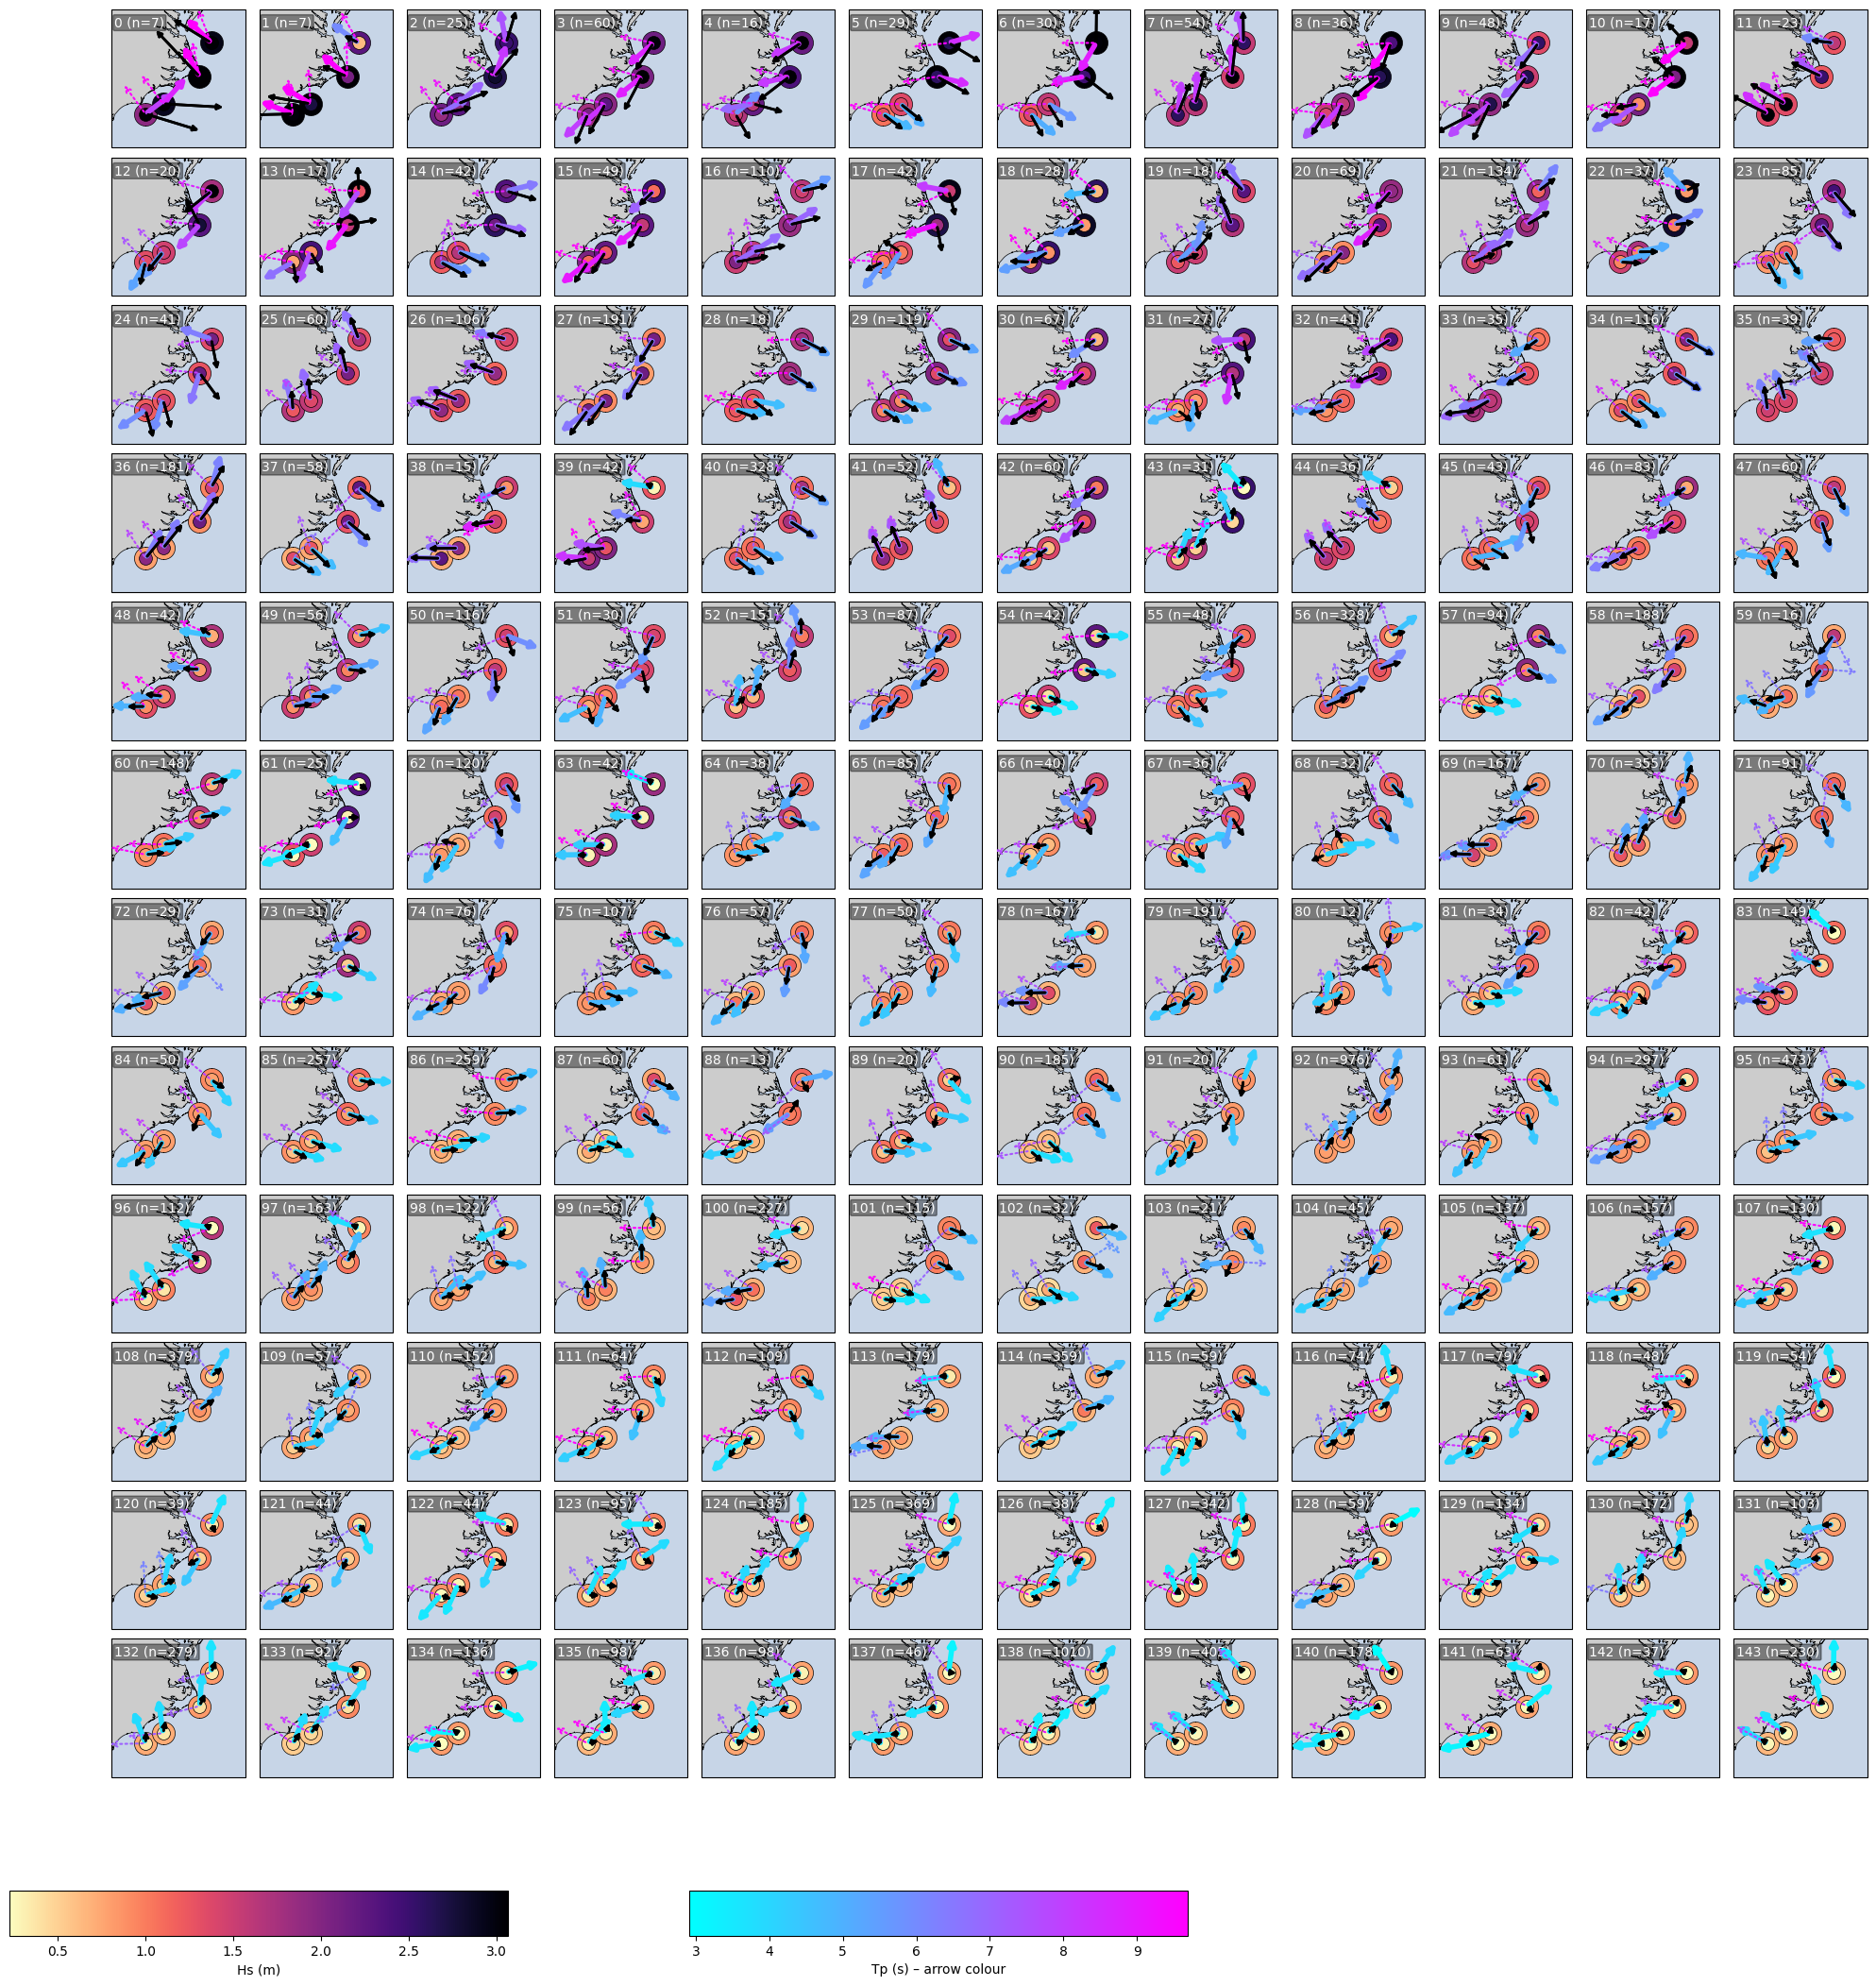

In [37]:

# --- 1. Centroids dataframe (1 row per cluster) ------------------------------

centroids = kma_sort.reset_index(drop=True)

# column groups (same as before)
hs0_cols = [f"hs0g{i}" for i in range(1, 5)]
hs1_cols = [f"hs1g{i}" for i in range(1, 5)]
tp0_cols = [f"tp0g{i}" for i in range(1, 5)]
tp1_cols = [f"tp1g{i}" for i in range(1, 5)]
dp0_cols = [f"dp0g{i}" for i in range(1, 5)]
dp1_cols = [f"dp1g{i}" for i in range(1, 5)]
ws0_cols = [f"ws0g{i}" for i in range(1, 5)]
wd0_cols = [f"wd0g{i}" for i in range(1, 5)]

# Wind speed scale for arrow length (deg per m/s) - 90th pct ws gives ~1.5 deg
all_ws = centroids[ws0_cols].to_numpy().ravel()
ws_scale = 1.5 / np.nanpercentile(all_ws, 90) if np.nanpercentile(all_ws, 90) > 0 else 0.2

# --- 2. Colour scales --------------------------------------------------------
# Hs for circles
all_hs = centroids[hs0_cols + hs1_cols].to_numpy().ravel()
vmin_hs, vmax_hs = np.percentile(all_hs, [2, 98])
norm_hs = Normalize(vmin=vmin_hs, vmax=vmax_hs, clip=True)
# norm_hs = Normalize(vmin=np.nanmin(all_hs), vmax=np.quantile(all_hs,.9))
cmap_hs = cm.get_cmap("magma_r")

# Tp for arrow colour & length
all_tp = centroids[tp0_cols + tp1_cols].to_numpy().ravel()
norm_tp = Normalize(vmin=np.nanmin(all_tp), vmax=np.quantile(all_tp,.9))
cmap_tp = cm.get_cmap("cool")

# cluster frame colours
n_clusters = len(centroids)
cluster_norm = Normalize(vmin=0, vmax=n_clusters - 1)
cluster_cmap = cm.get_cmap("tab20", n_clusters)

# --- cluster sizes (number of states per cluster) -----------------------------
cluster_counts = None
if "nearest_centroids_idxs_waves" in globals() and "kma_bmus_sorted" in nearest_centroids_idxs_waves.columns:
    counts = nearest_centroids_idxs_waves["kma_bmus_sorted"].value_counts()
    # reindex to [0, 1, ..., n_clusters-1] so cid can be used directly
    cluster_counts = counts.reindex(range(n_clusters)).fillna(0).astype(int)

# --- 3. Map extent from TARGET_POINTS ----------------------------------------
lats = [p["lat"] for p in TARGET_POINTS.values()]
lons = [p["lon"] for p in TARGET_POINTS.values()]
lon_min, lon_max = min(lons) - 1.5 , max(lons) + 1.5
lat_min, lat_max = min(lats) - 1.5, max(lats) + 1.5

# --- 4. Layout of small maps -------------------------------------------------
n_cols = 12
n_rows = 12  

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(2.0 * n_cols, 2.0 * n_rows),   # wide, not too tall
    subplot_kw={"projection": ccrs.PlateCarree()}
)

axes = np.atleast_2d(axes)
plt.subplots_adjust(wspace=0.1, hspace=0.07, bottom=0.1)

for cid in range(n_clusters):
    r = cid // n_cols
    c = cid % n_cols
    ax = axes[r, c]

    # background coast
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="0.8", linewidth=0)
    ax.add_feature(cfeature.OCEAN, facecolor="lightsteelblue", alpha=0.7, linewidth=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="k")

    # label cluster id + n states in top-left
    if cluster_counts is not None:
        n_states = int(cluster_counts.iloc[cid])
        label = f"{cid} (n={n_states})"
    else:
        label = f"{cid}"
    ax.text(0.02, 0.95, label, transform=ax.transAxes,
            ha="left", va="top", fontsize=10, color="white",
            bbox=dict(facecolor="black", alpha=0.4, boxstyle="round,pad=0.1"))

    # plot 4 points with circles and arrows
    for gi in range(1, 5):
        pt = TARGET_POINTS[f"grid{gi}"]
        lat = pt["lat"]
        lon = pt["lon"]
        
        # Hs0 / Hs1 colours
        hs0 = centroids.loc[cid, f"hs0g{gi}"]
        hs1 = centroids.loc[cid, f"hs1g{gi}"]
        col_hs0 = cmap_hs(norm_hs(hs0))
        col_hs1 = cmap_hs(norm_hs(hs1))

        # outer circle (hs1), inner circle (hs0)
        ax.scatter(lon, lat, s=300, color=col_hs1, edgecolor="k",
                   linewidths=0.5, transform=ccrs.PlateCarree(), zorder=3)
        ax.scatter(lon, lat, s=100, color=col_hs0, edgecolor="k",
                   linewidths=0.5, transform=ccrs.PlateCarree(), zorder=4)

        # arrows for sea (0) and swell (1)
        for part, tp_cols, dp_cols, linestyle, lw, arrowstyle in [
            (0, tp0_cols, dp0_cols, "-", 4.0, "-|>"),   # sea: thicker, solid, full head
            (1, tp1_cols, dp1_cols, ":", 1.5, "->"),    # swell: thinner, dashed, simple head
        ]:
            tp = centroids.loc[cid, tp_cols[gi - 1]]
            dp = centroids.loc[cid, dp_cols[gi - 1]]

            if np.isnan(tp) or np.isnan(dp):
                continue

            # colour from Tp; fixed length for visibility
            tpn = norm_tp(tp)
            length_deg = 1.7  # fixed length, visible
            theta = np.deg2rad(dp + 180)

            dx = length_deg * np.sin(theta)
            dy = length_deg * np.cos(theta)

            arrow_color = cmap_tp(tpn)

            arrow = FancyArrowPatch(
                (lon, lat),
                (lon + dx, lat + dy),
                transform=ccrs.PlateCarree(),
                arrowstyle=arrowstyle,
                linewidth=lw,
                linestyle=linestyle,
                color=arrow_color,
                mutation_scale=10,
                zorder=5,
            )
            ax.add_patch(arrow)

            # black wind arrows (wd0 = direction, ws0 = magnitude/length)
            ws0 = centroids.loc[cid, f"ws0g{gi}"]
            wd0 = centroids.loc[cid, f"wd0g{gi}"]
            if not (np.isnan(ws0) or np.isnan(wd0) or ws0 <= 0):
                length_deg = ws0 * ws_scale
                theta = np.deg2rad(wd0 + 180)  # meteorological: wd = from, arrow = toward
                dx = length_deg * np.sin(theta)
                dy = length_deg * np.cos(theta)
                wind_arrow = FancyArrowPatch(
                    (lon, lat),
                    (lon + dx, lat + dy),
                    transform=ccrs.PlateCarree(),
                    arrowstyle="-|>",
                    linewidth=2,
                    linestyle="-",
                    color="black",
                    mutation_scale=8,
                    zorder=6,
                )
                ax.add_patch(wind_arrow)

        ax.set_xticks([])
        ax.set_yticks([])

# Hide any unused axes (if n_clusters < n_rows*n_cols)
for cid in range(n_clusters, n_rows * n_cols):
    r = cid // n_cols
    c = cid % n_cols
    axes[r, c].set_visible(False)

# --- colorbars at the bottom (below plots) -------------------------------------------
sm_hs = plt.cm.ScalarMappable(norm=norm_hs, cmap=cmap_hs)
sm_hs.set_array([])

sm_tp = plt.cm.ScalarMappable(norm=norm_tp, cmap=cmap_tp)
sm_tp.set_array([])

# sm_cluster = plt.cm.ScalarMappable(norm=cluster_norm, cmap=cluster_cmap)
# sm_cluster.set_array([])

cax_hs = fig.add_axes([0.08, 0.03, 0.22, 0.02])
cax_tp = fig.add_axes([0.38, 0.03, 0.22, 0.02])
# cax_cl = fig.add_axes([0.68, 0.03, 0.22, 0.02])

cbar_hs = fig.colorbar(sm_hs, cax=cax_hs, orientation='horizontal')
cbar_tp = fig.colorbar(sm_tp, cax=cax_tp, orientation='horizontal')
# cbar_cl = fig.colorbar(sm_cluster, cax=cax_cl, orientation='horizontal')

cbar_hs.set_label('Hs (m)')
cbar_tp.set_label('Tp (s) – arrow colour')
# cbar_cl.set_label('Cluster index')

# Save figure
fig.savefig(f'outputs/Figures/maps_clusters_sorted.png', dpi=150, bbox_inches='tight')

plt.show()

In [38]:
sorted_idxs = [0, 1, 2, 3, 4, 5,6,7]+list(sorted_id[0:8])
sorted_idxs


[0, 1, 2, 3, 4, 5, 6, 7, 138, 92, 95, 139, 108, 125, 114, 70]